In [1]:
print("Hello World!")

Hello World!


## Import Libraries + Data

In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm # colormaps
# plt.style.use("dark_background")
import seaborn as sns
import math

from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error, silhouette_score, silhouette_samples, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, LabelEncoder, MinMaxScaler
from sklearn.svm import SVR
from imblearn.over_sampling import SMOTE
# import xgboost as xgb

import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
# !pip install tensorflow

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df_data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
%skip
df_data = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_data.head()

UsageError: Line magic function `%skip` not found.


## EDA, Data Visualization

In [6]:
df = df_data.copy()
df.drop('customerID', axis = 'columns', inplace = True)
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df1 = df[df.TotalCharges!= ' ']
df1.shape

(7032, 20)

In [10]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)
df1.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [11]:
# Identify categorical and numerical columns
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns
categorical_cols, numerical_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod', 'Churn'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

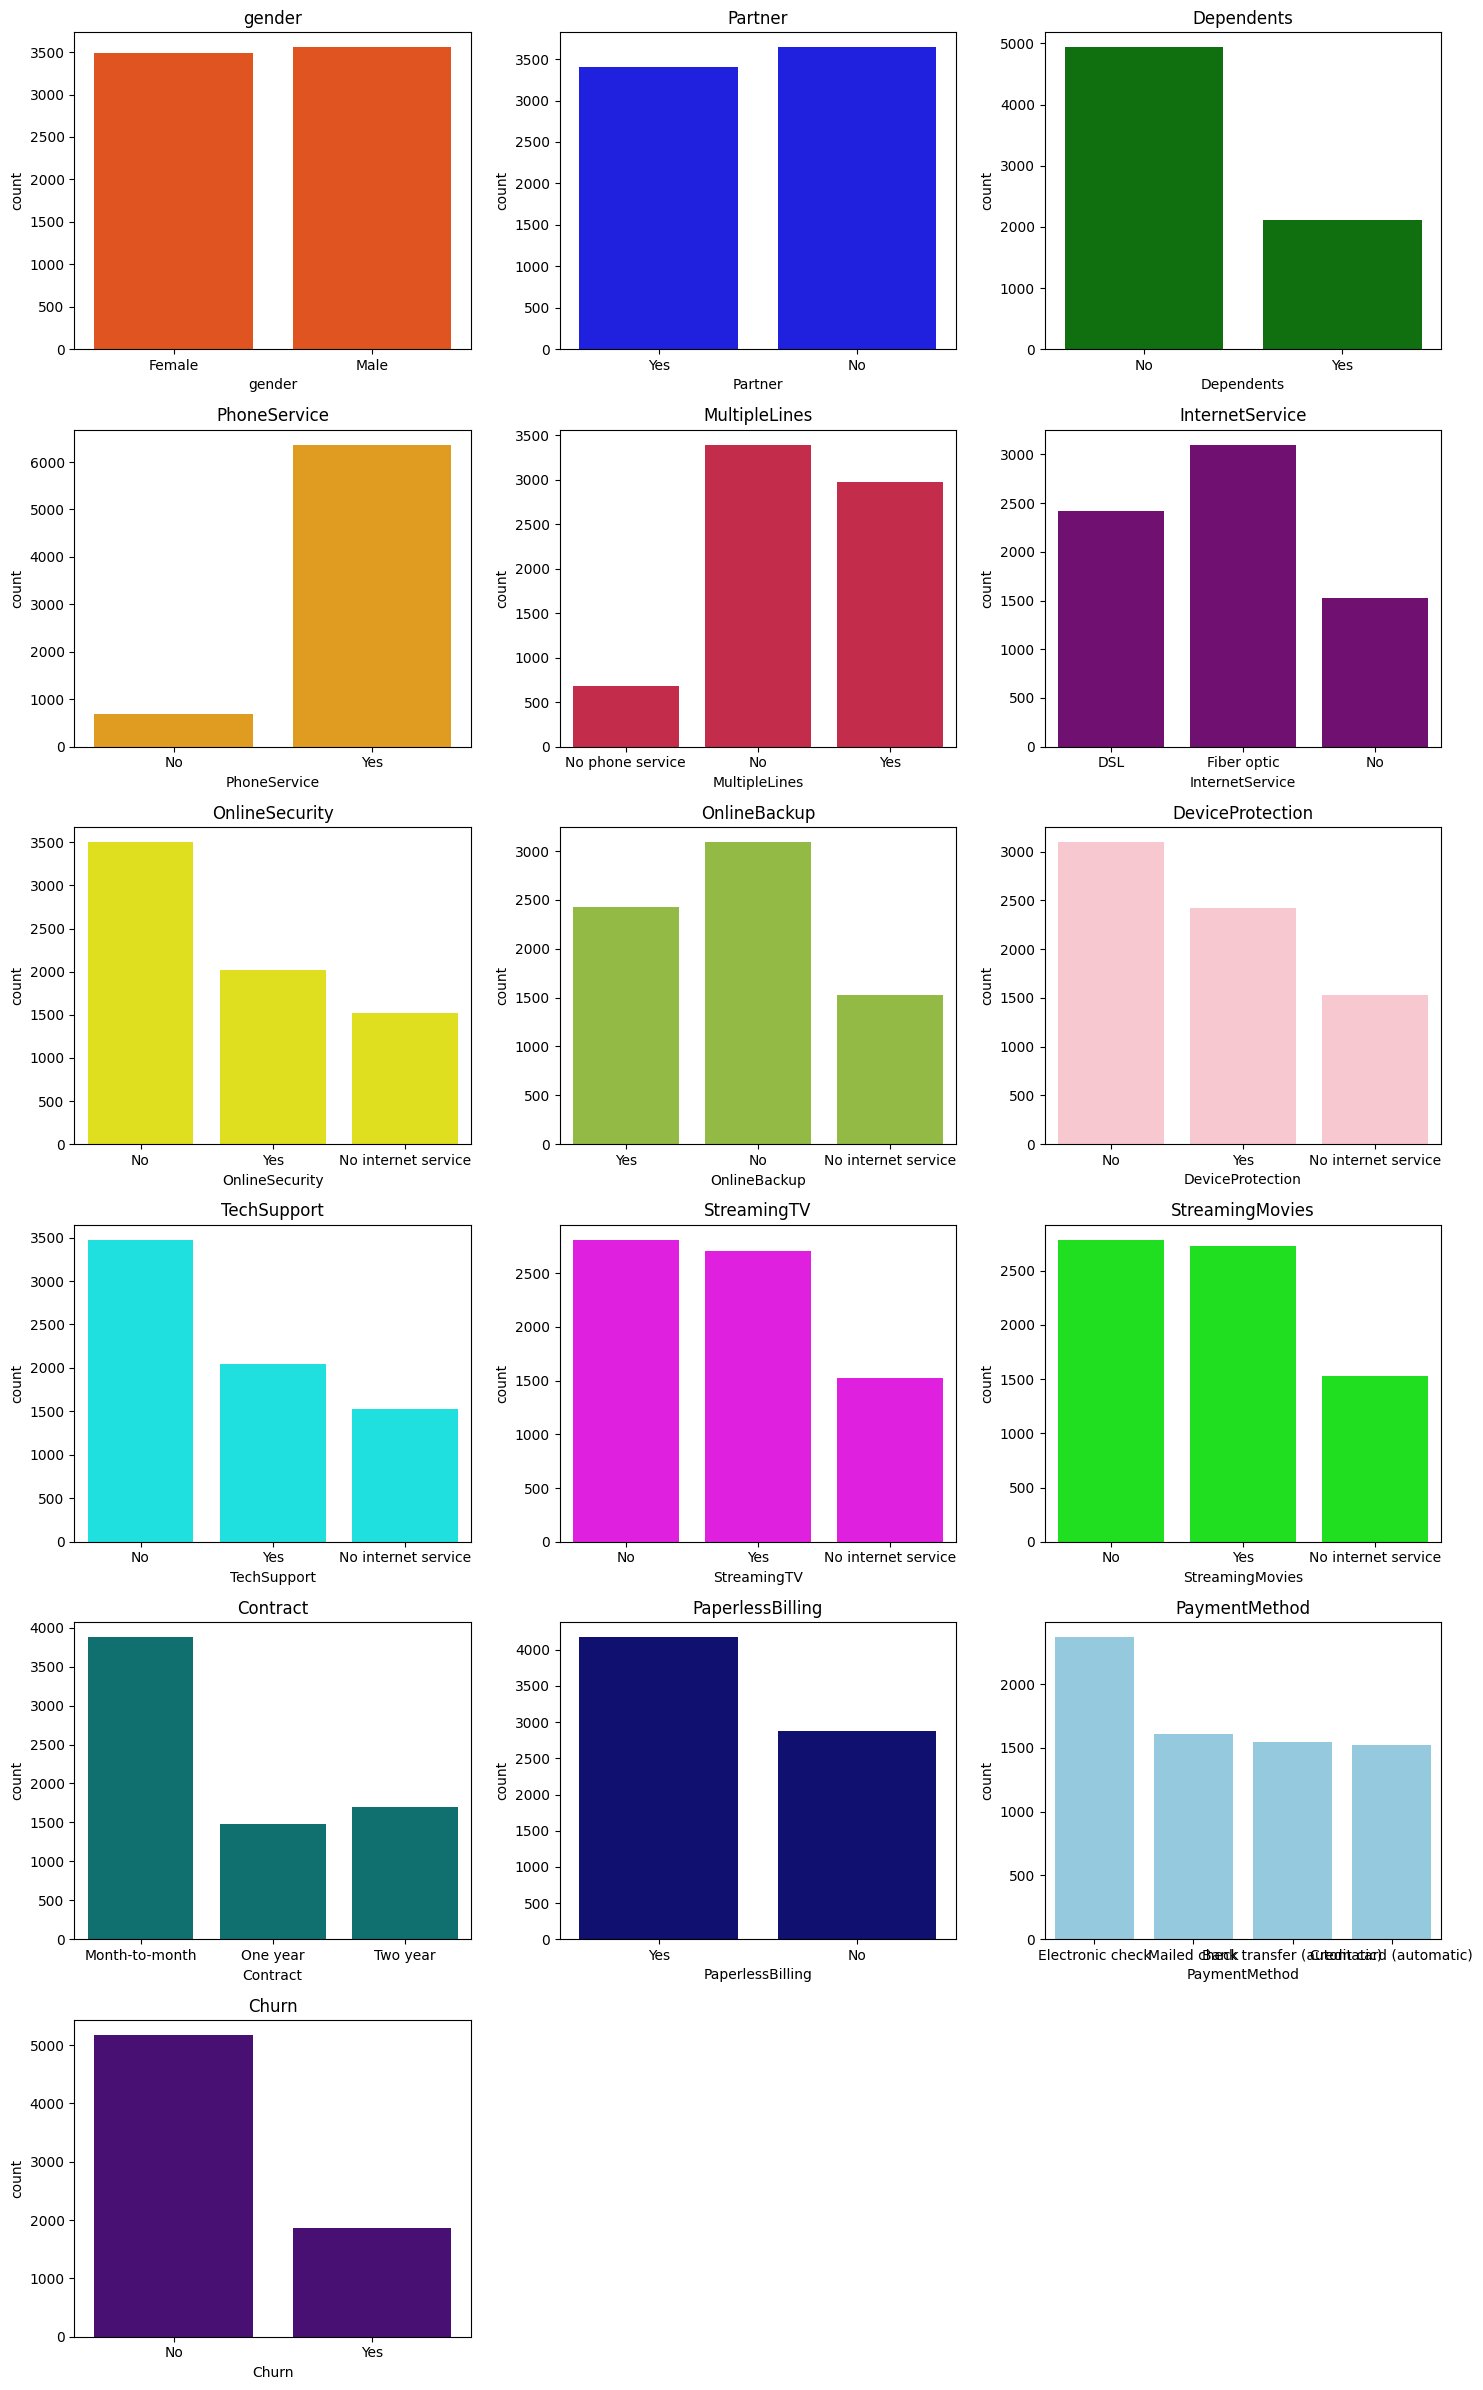

In [12]:
# colors
available_colors = list(mpl.colors.cnames.keys())

available_colors = [
    'orangered', 'blue', 'green', 'orange', 'crimson', 'purple',
    'yellow', 'yellowgreen', 'pink', 'cyan', 'magenta', 'lime', 'teal',
    'navy', 'skyblue', 'indigo', 'blueviolet', 'beige',
    'plum', 'orchid', 'crimson', 'darkgreen'
]
# number of plots
n = len(categorical_cols)

# grid size (auto)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[i], 
        color=available_colors[i % len(available_colors)]
    )
    axes[i].set_title(col)

# remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

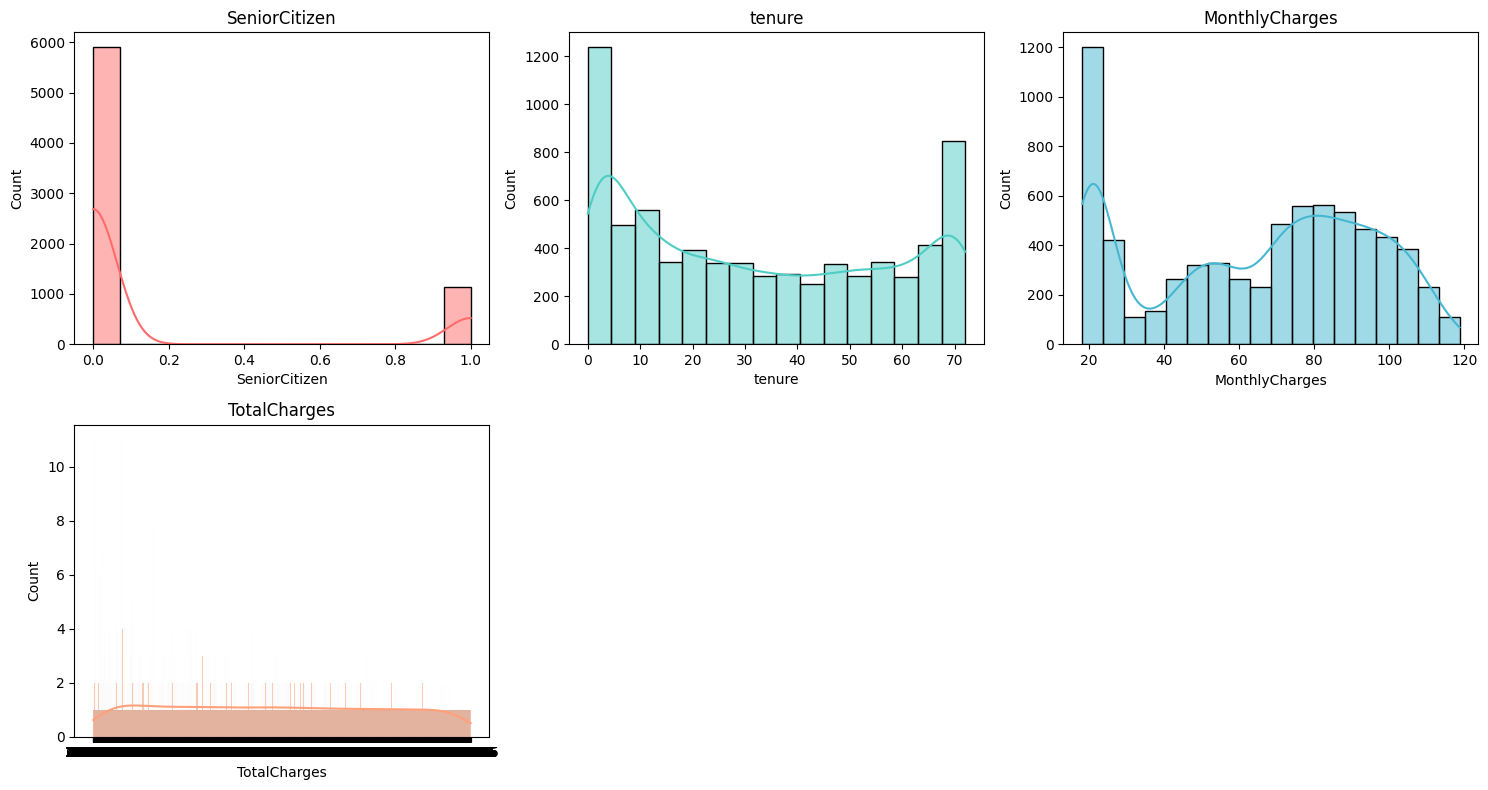

In [13]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# colors
available_colors = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A',
    '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9',
    '#F1948A', '#52BE80', '#5DADE2', '#AF7AC5'
]

# number of plots
n = len(numerical_cols)

# grid size
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        ax=axes[i],
        color=available_colors[i % len(available_colors)],
        kde=True   # optional
    )
    axes[i].set_title(col)

# remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

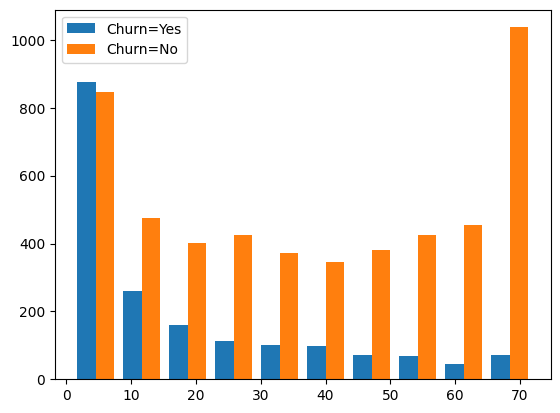

In [14]:
tenure_churn_no = df1[df1.Churn == 'No'].tenure
tenure_churn_yes = df1[df1.Churn == 'Yes'].tenure

plt.hist([tenure_churn_yes, tenure_churn_no], label=['Churn=Yes','Churn=No'])
plt.legend()

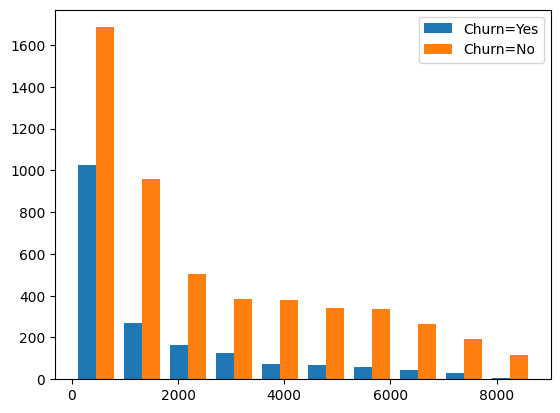

In [15]:
tc_churn_no = df1[df1.Churn == 'No'].TotalCharges
tc_churn_yes = df1[df1.Churn == 'Yes'].TotalCharges

plt.hist([tc_churn_yes, tc_churn_no], label=['Churn=Yes','Churn=No'])
plt.legend()

## Null values, Duplicates, Encoding

In [16]:
# Create the LabelEncoder instance
le = LabelEncoder()

# Dictionary to store encoders for each column
label_encoders = {}

# Loop through each categorical column and encode
for col in categorical_cols:
    le = LabelEncoder()
    df1[col + '_encoded'] = le.fit_transform(df1[col])
    label_encoders[col] = le  # Save encoder for later inverse transform


In [17]:
# ✅ Get mapping for churn column only
churn_mapping = dict(zip(label_encoders['Churn'].classes_,
                         label_encoders['Churn'].transform(label_encoders['Churn'].classes_)))

print("Churn Mapping (from → to):", churn_mapping)

Churn Mapping (from → to): {'No': 0, 'Yes': 1}


In [18]:
df2 = df1.drop(categorical_cols, axis = 1)
df2.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded,MultipleLines_encoded,InternetService_encoded,OnlineSecurity_encoded,OnlineBackup_encoded,DeviceProtection_encoded,TechSupport_encoded,StreamingTV_encoded,StreamingMovies_encoded,Contract_encoded,PaperlessBilling_encoded,PaymentMethod_encoded,Churn_encoded
0,0,1,29.85,29.85,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
2,0,2,53.85,108.15,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


In [19]:
df2.dtypes

SeniorCitizen                 int64
tenure                        int64
MonthlyCharges              float64
TotalCharges                float64
gender_encoded                int64
Partner_encoded               int64
Dependents_encoded            int64
PhoneService_encoded          int64
MultipleLines_encoded         int64
InternetService_encoded       int64
OnlineSecurity_encoded        int64
OnlineBackup_encoded          int64
DeviceProtection_encoded      int64
TechSupport_encoded           int64
StreamingTV_encoded           int64
StreamingMovies_encoded       int64
Contract_encoded              int64
PaperlessBilling_encoded      int64
PaymentMethod_encoded         int64
Churn_encoded                 int64
dtype: object

In [20]:
# Create the scaler (default range 0 to 1)
scaler = MinMaxScaler()

# Fit and transform the numerical columns
df_scaled = pd.DataFrame(
    scaler.fit_transform(df2),
    columns=df2.columns
)

df_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded,MultipleLines_encoded,InternetService_encoded,OnlineSecurity_encoded,OnlineBackup_encoded,DeviceProtection_encoded,TechSupport_encoded,StreamingTV_encoded,StreamingMovies_encoded,Contract_encoded,PaperlessBilling_encoded,PaymentMethod_encoded,Churn_encoded
0,0.0,0.000000,0.115423,0.001275,0.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.666667,0.0
1,0.0,0.464789,0.385075,0.215867,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.5,0.0,1.000000,0.0
2,0.0,0.014085,0.354229,0.010310,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,1.0
3,0.0,0.619718,0.239303,0.210241,1.0,0.0,0.0,0.0,0.5,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.5,0.0,0.000000,0.0
4,0.0,0.014085,0.521891,0.015330,0.0,0.0,0.0,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.666667,1.0


## Model fitting, Evaluation

In [21]:
X = df_scaled.drop('Churn_encoded', axis = 1)
y = df_scaled['Churn_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 19), (1407, 19), (5625,), (1407,))

In [23]:
len(X_train.columns)

19

## Before SMOTE

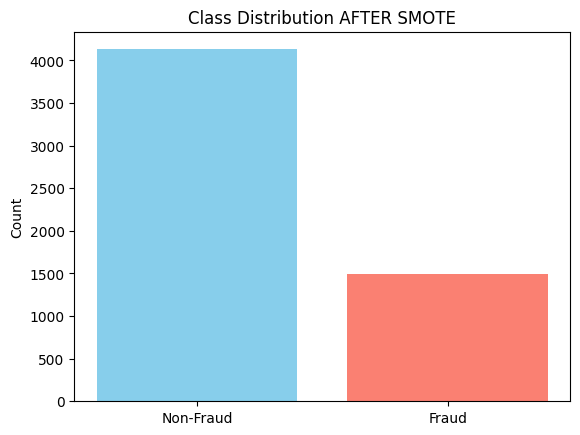

In [33]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [24]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(16, input_shape = (19,), activation = 'relu'),
    keras.layers.Dense(8, activation = 'relu'),
    keras.layers.Dense(1, activation = 'sigmoid')
    
])

model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy']
             )

model.fit(X_train, y_train, epochs = 20)

I0000 00:00:1780559556.250875    2781 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780559585.416316    2781 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780559599.268282    2781 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1780559601.686285    2781 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7001 - loss: 0.5669
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7730 - loss: 0.4563
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7888 - loss: 0.4343
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7948 - loss: 0.4281
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7979 - loss: 0.4244
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8036 - loss: 0.4211
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8046 - loss: 0.4187
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8028 - loss: 0.4185
Epoch 9/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8043 - loss: 0.4171
Epoch 10/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8062 - loss: 0.4153
Epoch 11/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8059 - loss: 0.4141
Epoch 12/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [25]:
model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7825 - loss: 0.4415


[0.44150862097740173, 0.7825160026550293]

In [26]:
y_pred = model.predict(X_test)
y_pred[:10]

 1/44 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.01401804],
       [0.17784266],
       [0.8234047 ],
       [0.19764218],
       [0.26646313],
       [0.41744342],
       [0.21667853],
       [0.80132467],
       [0.26829687],
       [0.02655312]], dtype=float32)

In [27]:
y_test[:10]

2476    0.0
6773    0.0
6116    1.0
3047    0.0
4092    0.0
3218    0.0
3768    0.0
3463    0.0
3414    0.0
1192    0.0
Name: Churn_encoded, dtype: float64

In [28]:
y_output = [1 if x >= 0.5 else 0 for x in y_pred]
y_output[:10]

[0, 0, 1, 0, 0, 0, 0, 1, 0, 0]

In [29]:
print(classification_report(y_test, y_output))

              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85      1033
         1.0       0.60      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



Text(45.722222222222214, 0.5, 'Actual')

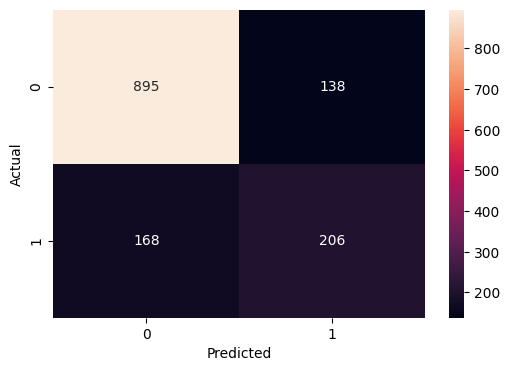

In [30]:
cm = tf.math.confusion_matrix(labels = y_test, predictions = y_output)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [31]:
print('precision 0:', 944 / (944 + 209), 'precision 1:', 165 / (165 + 89))
print('recall 0:', 944 / (944 + 89), 'recall 1:', 165 / (165 + 209))

precision 0: 0.818733738074588 precision 1: 0.6496062992125984
recall 0: 0.9138431752178122 recall 1: 0.4411764705882353


## After SMOTE

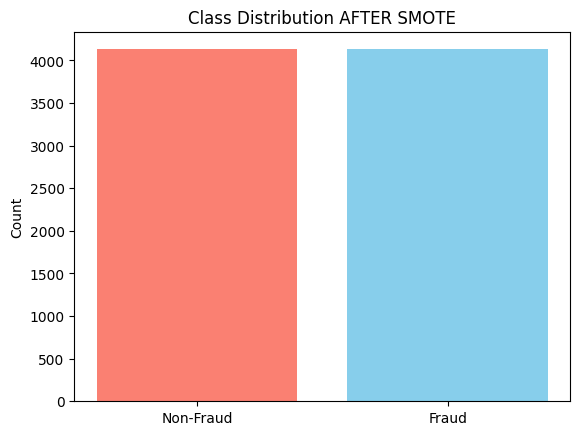

In [32]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [34]:
model.fit(X_train_sm, y_train_sm)

y_pred_sm = model.predict(X_test)

# print("Accuracy AFTER SMOTE:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
# print("Classification Report AFTER SMOTE:\n", classification_report(y_test, y_pred_sm))

# sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix AFTER SMOTE")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7753 - loss: 0.4648
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


In [35]:
y_output_sm = [1 if x >= 0.5 else 0 for x in y_pred_sm]
print(classification_report(y_test, y_output_sm))

              precision    recall  f1-score   support

         0.0       0.89      0.74      0.81      1033
         1.0       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



Text(45.722222222222214, 0.5, 'Actual')

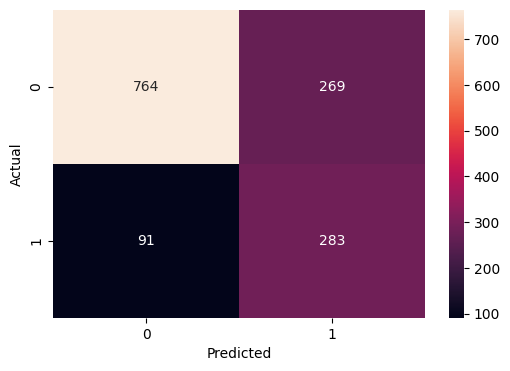

In [37]:
cm = tf.math.confusion_matrix(labels = y_test, predictions = y_output_sm)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')